In [3]:
import duckdb
import pandas as pd

con = duckdb.connect('../../warehouse.duckdb')

df = con.execute("""
    select
        c.user_id,
        date_trunc('month', c.first_seen_date) as cohort_month,
        o.order_date,
        o.revenue
    from main.stg_customers c
    join main.fct_orders o on c.user_id = o.user_id
""").fetchdf()

df.head()

,user_id,cohort_month,order_date,revenue
0,u_000001,2024-10-01,2024-11-16,195.96
1,u_000010,2025-04-01,2025-04-13,140.65
2,u_000015,2025-06-01,2025-11-13,90.83
3,u_000024,2025-07-01,2025-07-10,114.09
4,u_000027,2024-10-01,2025-01-11,86.58


In [4]:
df['months_since_acquisition'] = (
    (df['order_date'].dt.year - df['cohort_month'].dt.year) * 12
    + (df['order_date'].dt.month - df['cohort_month'].dt.month)
)

cohort_sizes = df.groupby('cohort_month')['user_id'].nunique()

monthly_revenue = (
    df.groupby(['cohort_month', 'months_since_acquisition'])['revenue']
    .sum()
    .reset_index()
)

monthly_revenue['cohort_size'] = monthly_revenue['cohort_month'].map(cohort_sizes)
monthly_revenue['revenue_per_customer'] = monthly_revenue['revenue'] / monthly_revenue['cohort_size']

monthly_revenue['cumulative_revenue_per_customer'] = (
    monthly_revenue.sort_values('months_since_acquisition')
    .groupby('cohort_month')['revenue_per_customer']
    .cumsum()
)

monthly_revenue.head(10)

,cohort_month,months_since_acquisition,revenue,cohort_size,revenue_per_customer,cumulative_revenue_per_customer
0,2024-08-01,1,105.81,1,105.810000,105.810000
1,2024-08-01,4,23.33,1,23.330000,129.140000
2,2024-08-01,7,29.63,1,29.630000,158.770000
3,2024-09-01,0,3941.00,62,63.564516,63.564516
4,2024-09-01,1,1768.49,62,28.524032,92.088548
5,2024-09-01,2,1369.27,62,22.085000,114.173548
6,2024-09-01,3,1139.64,62,18.381290,132.554839
7,2024-09-01,4,362.23,62,5.842419,138.397258
8,2024-09-01,5,919.39,62,14.828871,153.226129
9,2024-09-01,6,472.02,62,7.613226,160.839355


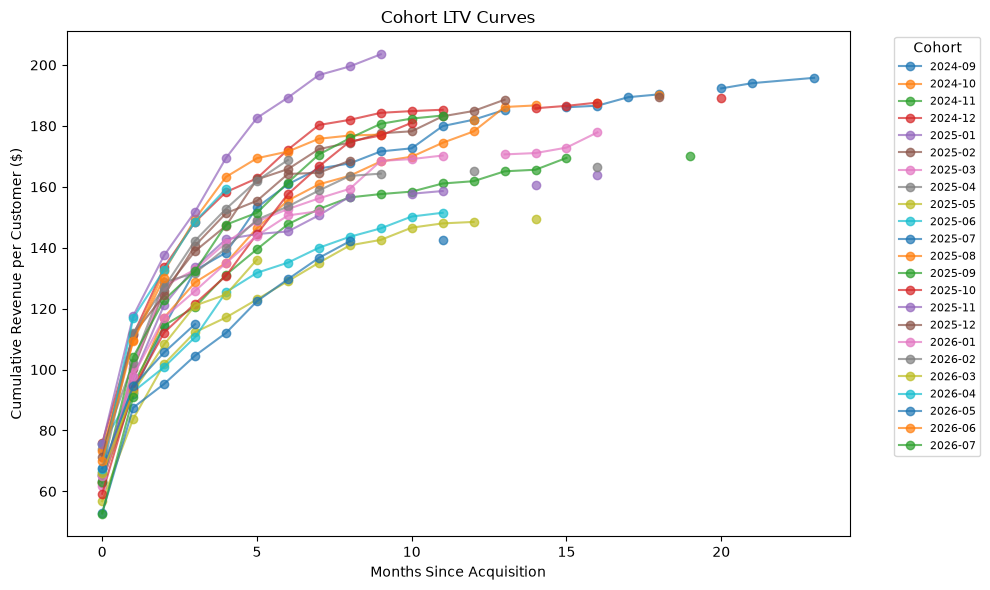

In [5]:
import matplotlib.pyplot as plt

# drop partial edge cohorts (first and last), which are artifacts of the
# data window's start/end date not aligning to calendar month boundaries
valid_cohorts = sorted(monthly_revenue['cohort_month'].unique())[1:-1]
plot_data = monthly_revenue[monthly_revenue['cohort_month'].isin(valid_cohorts)]

pivot = plot_data.pivot(
    index='cohort_month',
    columns='months_since_acquisition',
    values='cumulative_revenue_per_customer'
)

fig, ax = plt.subplots(figsize=(10, 6))
for cohort_month, row in pivot.iterrows():
    ax.plot(row.index, row.values, marker='o', label=cohort_month.strftime('%Y-%m'), alpha=0.7)

ax.set_xlabel('Months Since Acquisition')
ax.set_ylabel('Cumulative Revenue per Customer ($)')
ax.set_title('Cohort LTV Curves')
ax.legend(title='Cohort', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Cohort LTV curves

Each line is one acquisition month cohort, tracking cumulative revenue per
customer from the month they first ordered onward. The curves flatten out
because of the active/dormant assumption in the data generator (P_DORMANT =
0.35). Once a customer goes dormant they stop buying, so their cohort's line
stops climbing and levels off.

Cohorts near the start and end of the 24 month window are excluded from this
chart. The data only covers a fixed 730 day range, so the first and last
calendar months don't line up with a full month of acquisitions. The August
2024 cohort for example only captures one day of real signups, which makes
it look artificially tiny if you leave it in.

Later cohorts also just have shorter lines since they haven't had as much
time to accumulate purchases yet, not because anything is missing.

Cumulative LTV per customer plateaus somewhere between $140 and $205
depending on the cohort. Next step is fitting BG/NBD and Gamma-Gamma to get
a predicted 12 month LTV per customer, then checking if that lines up with
which channels look best under MTA/ROAS.